# Detecção de Fraude em Cartão de Crédito com XGBoost 💳

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, auc

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


<Axes: xlabel='Class', ylabel='count'>

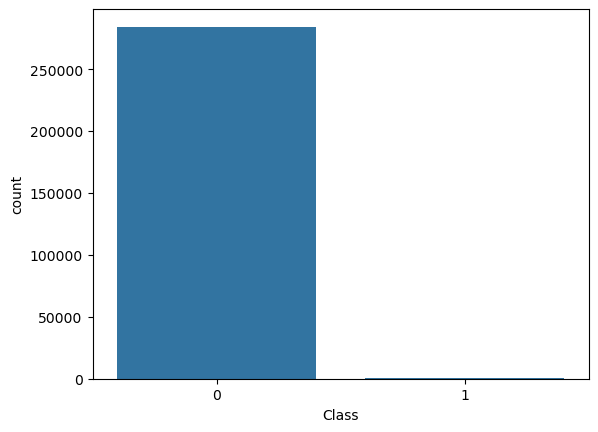

In [4]:
sns.countplot(x='Class', data=df)

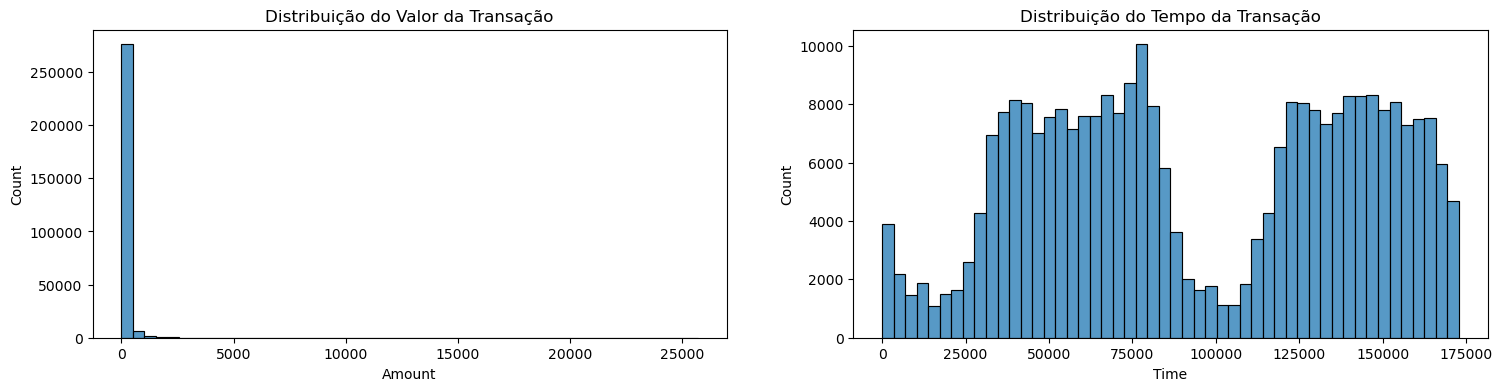

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], ax=ax[0], bins=50)
ax[0].set_title('Distribuição do Valor da Transação')

sns.histplot(df['Time'], ax=ax[1], bins=50)
ax[1].set_title('Distribuição do Tempo da Transação')

plt.show();

In [6]:
scaler = StandardScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [8]:
y = df['Class']
x = df.drop('Class', axis=1)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
print("Proporção de fraudes no y_test:", y_test.value_counts(normalize=True)[1])

Proporção de fraudes no y_test: 0.0017321489179921118


In [11]:
print("Proporção de fraudes no y_train:", y_train.value_counts(normalize=True)[1])

Proporção de fraudes no y_train: 0.0017254870488152324


In [12]:
counts = y_train.value_counts()
scale_pos_weight = counts[0] / counts[1]
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

Scale Pos Weight: 578.55


In [13]:
model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

In [14]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



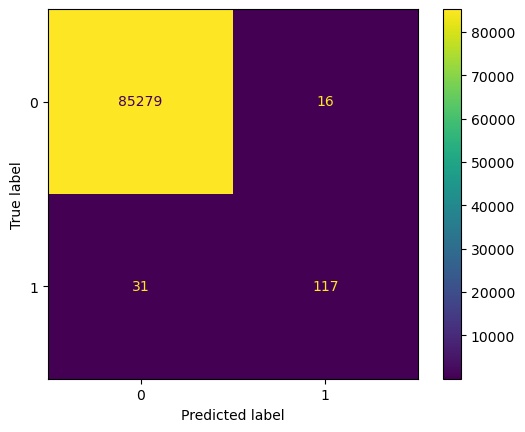

In [16]:
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test);

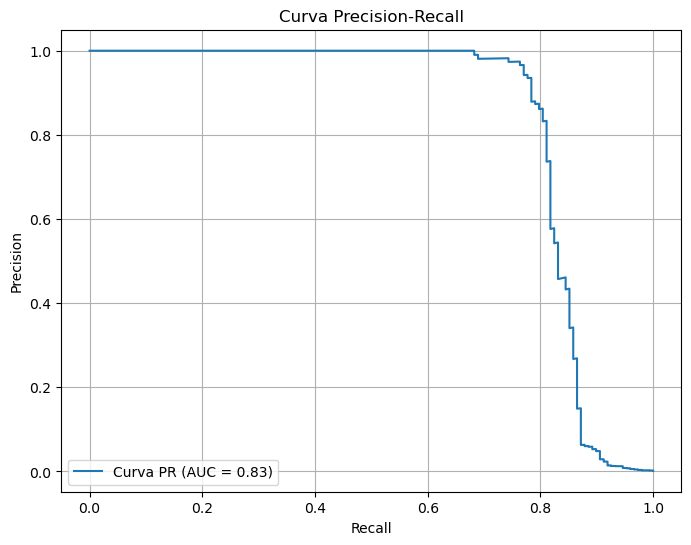

In [17]:
y_probs = model.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Curva PR (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show();

# ✅ Conclusão Final e Resultados do Modelo

Este projeto demonstrou a construção de um pipeline de Machine Learning de alta performance para o complexo desafio de **detecção de fraude em transações de cartão de crédito**. O foco foi lidar com o extremo desbalanceamento do dataset e aplicar um algoritmo avançado para obter resultados precisos e acionáveis.

### Resumo do Processo

1.  **Análise Exploratória:** A análise inicial confirmou o principal desafio do projeto: as transações fraudulentas (`Class = 1`) representam menos de 0.2% do total de dados, caracterizando um problema de classificação severamente desbalanceado.

2.  **Pré-processamento:** As features `Time` e `Amount` foram dimensionadas usando `StandardScaler` para que tivessem uma escala comparável às features anonimizadas (V1-V28). A divisão dos dados em conjuntos de treino e teste foi feita de forma **estratificada** para garantir que a proporção de fraudes fosse a mesma em ambos os conjuntos.

3.  **Modelagem com XGBoost:** Foi utilizado o `XGBClassifier`, um poderoso algoritmo de Gradient Boosting. Para combater o desbalanceamento, foi empregado o hiperparâmetro `scale_pos_weight`, que instrui o modelo a dar uma importância muito maior aos exemplos de fraude durante o treinamento.

### Resultados e Performance

O modelo treinado apresentou um desempenho **excepcional** no conjunto de teste, validando a eficácia da abordagem:

*   **Acurácia Geral:** Praticamente **100%**, o que é esperado em datasets desbalanceados, mas não é a métrica principal.
*   **Performance na Detecção de Fraudes (Classe `1`):**
    *   🎯 **Recall de 79%:** O modelo foi capaz de identificar corretamente **79% de todas as transações fraudulentas reais**. Este é um resultado fantástico, indicando que a grande maioria das fraudes seria detectada pelo sistema.
    *   🛡️ **Precisão de 88%:** De todas as transações que o modelo sinalizou como fraude, **88% delas eram de fato fraudulentas**. Isso demonstra uma baixa taxa de "alarmes falsos", o que é crucial para a eficiência da equipe de prevenção a fraudes.

*   **Curva Precision-Recall:** A análise da curva P-R confirmou a robustez do modelo, com uma **Área Sob a Curva (AUC) de 0.83**. Isso indica um excelente poder de discriminação entre transações legítimas e fraudulentas em diferentes limiares de decisão.

**Conclusão Final:** A combinação de pré-processamento cuidadoso (estratificação), um algoritmo avançado (XGBoost) e uma técnica específica para dados desbalanceados (`scale_pos_weight`) resultou em um modelo de detecção de fraude altamente eficaz e confiável, pronto para gerar um impacto significativo no negócio.